# 07  ·  Live-prediction demo

The interactive cell at the bottom of this notebook is the on-stage demo
for the talk. It picks a random held-out trial, shows the 22-channel EEG,
and displays both models' class-probability bars side-by-side.

Re-run the demo cell during the talk for each audience prediction.

In [1]:
# Make the eeg_cognitive package importable when running this notebook
# directly out of a clone (no pip install required).
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)


In [2]:
import os, sys, time, random
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from eeg_cognitive import (make_motor_imagery_synthetic, preprocess_epochs,
                          ChannelStandardizer, CHANNELS_22)
from eeg_cognitive.models import FBCSPClassifier, EEGNetClassifier
from eeg_cognitive.viz import plot_confusion_matrix
print('OK')


OK


## Stratified 80/20 split, train both models

In [3]:
ds = make_motor_imagery_synthetic(n_subjects=2, trials_per_class=14,
                                  snr_db=-12, seed=0)
X = preprocess_epochs(ds.X, ds.sfreq)
idx_tr, idx_demo = train_test_split(np.arange(len(ds.y)), test_size=0.2,
                                    stratify=ds.y, random_state=42)
sc = ChannelStandardizer().fit(X[idx_tr])
Xtr, ytr = sc.transform(X[idx_tr]), ds.y[idx_tr]
Xdm, ydm = sc.transform(X[idx_demo]), ds.y[idx_demo]
print(f'train {Xtr.shape}  demo {Xdm.shape}  classes {ds.class_names}')

t0 = time.time()
fb = FBCSPClassifier(sfreq=ds.sfreq, n_components=4, n_features=20).fit(Xtr, ytr)
print(f'FBCSP fit {time.time()-t0:.1f}s')
t0 = time.time()
en = EEGNetClassifier(epochs=20, batch_size=64, lr=1.5e-3, weight_decay=1e-4,
                      patience=8, val_frac=0.2, seed=0)
en.sfreq = ds.sfreq; en.eegnet_kernel_length = max(16, int(ds.sfreq // 4))
en.fit(Xtr, ytr)
print(f'EEGNet fit {time.time()-t0:.1f}s, {sum(p.numel() for p in en.model_.parameters())} params')


train (89, 22, 500)  demo (23, 22, 500)  classes ['left_hand', 'right_hand', 'feet', 'tongue']


FBCSP fit 0.4s


EEGNet fit 2.3s, 2404 params


## The live cell — re-run for every audience prediction

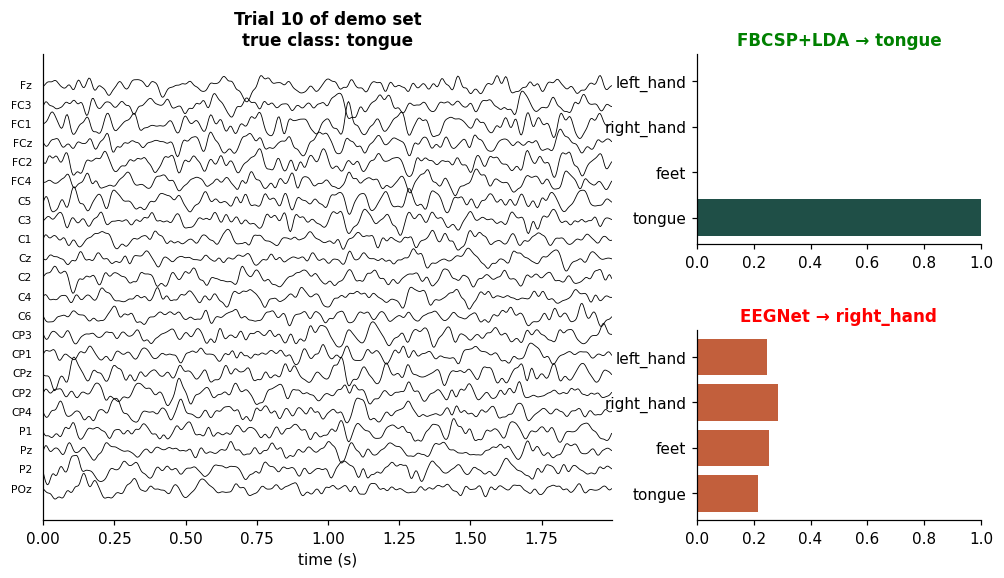

('tongue', 'tongue', 'right_hand')

In [4]:
def predict_one(trial_idx=None):
    if trial_idx is None: trial_idx = random.randrange(len(Xdm))
    trial = Xdm[trial_idx]; truth = ds.class_names[ydm[trial_idx]]
    fb_p = fb.predict_proba(trial[None, ...])[0]
    en_p = en.predict_proba(trial[None, ...])[0]

    fig = plt.figure(figsize=(11, 5.5))
    gs = fig.add_gridspec(2, 2, width_ratios=[2, 1], hspace=0.45)
    a_eeg = fig.add_subplot(gs[:, 0])
    a_fb  = fig.add_subplot(gs[0, 1])
    a_en  = fig.add_subplot(gs[1, 1])

    n_ch, n_t = trial.shape
    t = np.arange(n_t) / ds.sfreq
    spacing = 4 * trial.std()
    for i in range(n_ch):
        a_eeg.plot(t, trial[i] + (n_ch - 1 - i) * spacing,
                   color='black', linewidth=0.55)
        a_eeg.text(-0.04, (n_ch - 1 - i)*spacing, CHANNELS_22[i],
                   ha='right', va='center', fontsize=7)
    a_eeg.set_xlim(0, t[-1]); a_eeg.set_yticks([])
    a_eeg.set_xlabel('time (s)')
    a_eeg.set_title(f'Trial {trial_idx} of demo set\ntrue class: {truth}',
                    fontweight='bold')

    a_fb.barh(ds.class_names, fb_p, color='#1F4F47')
    fb_top = ds.class_names[fb_p.argmax()]
    a_fb.set_title(f'FBCSP+LDA → {fb_top}',
                   color='green' if fb_top == truth else 'red')
    a_fb.invert_yaxis(); a_fb.set_xlim(0, 1)

    a_en.barh(ds.class_names, en_p, color='#C25F3C')
    en_top = ds.class_names[en_p.argmax()]
    a_en.set_title(f'EEGNet → {en_top}',
                   color='green' if en_top == truth else 'red')
    a_en.invert_yaxis(); a_en.set_xlim(0, 1)
    plt.show()
    return truth, fb_top, en_top

random.seed(7)
predict_one()


## Replay across the full demo set

FBCSP demo-set acc:  100.0%
EEGNet demo-set acc:  43.5%


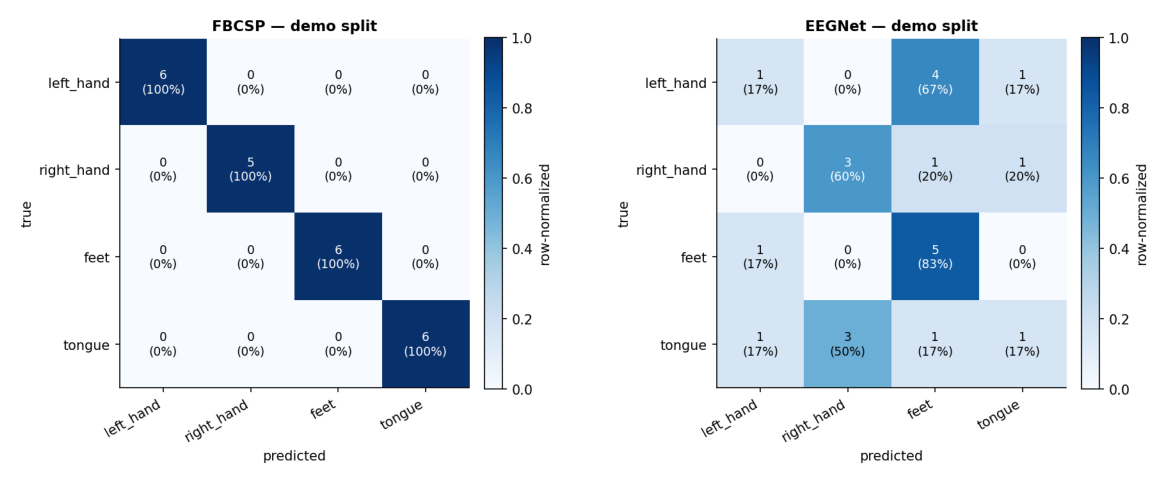

In [5]:
fb_pred = fb.predict(Xdm)
en_pred = en.predict(Xdm)
print(f'FBCSP demo-set acc:  {accuracy_score(ydm, fb_pred)*100:5.1f}%')
print(f'EEGNet demo-set acc: {accuracy_score(ydm, en_pred)*100:5.1f}%')

cm_fb = confusion_matrix(ydm, fb_pred, labels=range(len(ds.class_names)))
cm_en = confusion_matrix(ydm, en_pred, labels=range(len(ds.class_names)))
os.makedirs('../results/figures/notebook_outputs', exist_ok=True)
plot_confusion_matrix(cm_fb, ds.class_names, 'FBCSP — demo split',
    '../results/figures/notebook_outputs/07_demo_fbcsp.png')
plot_confusion_matrix(cm_en, ds.class_names, 'EEGNet — demo split',
    '../results/figures/notebook_outputs/07_demo_eegnet.png')

import matplotlib.image as mpimg
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].imshow(mpimg.imread('../results/figures/notebook_outputs/07_demo_fbcsp.png'))
ax[0].axis('off')
ax[1].imshow(mpimg.imread('../results/figures/notebook_outputs/07_demo_eegnet.png'))
ax[1].axis('off')
plt.tight_layout(); plt.show()
